
# Notebook 11 (V4.3) - Blue-line `vartheta_US = 0.80` NFA decompositions

This notebook solves the single all-`u` equilibrium path corresponding to the blue line in section 8 of `09_v9_phi_decay_aUS_sweeps.ipynb`:

- outer sweep: `vartheta_US = 0.80`
- scenario: `us_only`
- blue inner line: `a_US = 0.20`, `a_W = 0.20`
- horizon: `T_max = 100`
- all other parameters: `ProductionParams()` defaults, including `vartheta_W = 0.50`

It then reports all all-`u` endogenous paths, the `Q_US/e_US` demand-vs-production decomposition used in `08_v9_parameter_sweeps.ipynb`, the NFA component view used in `08_v9_parameter_sweeps.ipynb` and `06_v9_nfa_decomposition.ipynb`, and an AHP-style current-account / valuation-effects accounting based on `On_NFA_decomposition_VA.md` and Figure 2 of Atkeson, Heathcote, and Perri (2025).


In [1]:

using Pkg; Pkg.activate(".")
include("TwoCountryProductionOLG.jl")

using Printf, Statistics, Plots, LaTeXStrings, Markdown
using Plots.PlotMeasures

gr()
OUTDIR = joinpath("outputs_v43", "blue_line_vartheta080")
mkpath(OUTDIR)

default(size=(980, 620), framestyle=:box, grid=:y, legend=:best,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=9mm, right_margin=6mm, top_margin=7mm, bottom_margin=8mm)


  Activating 

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


In [2]:

late_range(T) = max(1, T - 19):T

function pretty(x)
    x === missing && return ""
    x isa Bool && return string(x)
    x isa Integer && return string(x)
    if x isa AbstractFloat
        if !isfinite(x)
            return string(x)
        elseif abs(x) >= 1000 || (abs(x) > 0 && abs(x) < 1e-3)
            return @sprintf("%.3e", x)
        else
            return @sprintf("%.4f", x)
        end
    end
    return string(x)
end

function html_escape(x)
    s = string(x)
    s = replace(s, "&" => "&amp;")
    s = replace(s, "<" => "&lt;")
    s = replace(s, ">" => "&gt;")
    s = replace(s, "\"" => "&quot;")
    return s
end

function show_html_table(rows, cols; maxrows=length(rows))
    shown = rows[1:min(maxrows, length(rows))]
    buf = IOBuffer()
    println(buf, "<div style=\"max-width:100%; overflow-x:auto; margin:0.4rem 0 1rem 0;\">")
    println(buf, "<table style=\"border-collapse:collapse; font-size:12px; line-height:1.25; white-space:nowrap;\">")
    println(buf, "<thead><tr>")
    for c in cols
        println(buf, "<th style=\"border-bottom:1px solid #999; padding:4px 8px; text-align:right;\">", html_escape(c), "</th>")
    end
    println(buf, "</tr></thead><tbody>")
    for row in shown
        println(buf, "<tr>")
        for c in cols
            println(buf, "<td style=\"border-bottom:1px solid #ddd; padding:3px 8px; text-align:right;\">", html_escape(pretty(get(row, c, missing))), "</td>")
        end
        println(buf, "</tr>")
    end
    if length(rows) > length(shown)
        println(buf, "<tr><td style=\"padding:3px 8px;\">...</td>")
        for _ in 2:length(cols)
            println(buf, "<td></td>")
        end
        println(buf, "</tr>")
    end
    println(buf, "</tbody></table></div>")
    display("text/html", String(take!(buf)))
end

function valid_core(result)
    R_A_u = [s.R_A_u for s in result.u_path]
    R_A_b = [s.R_A_b for s in result.u_path]
    return result.branch_converged && result.max_u_residual <= 1e-5 &&
           result.max_bgp_residual <= 1e-5 &&
           result.diagnostics.psi_ok && result.diagnostics.equity_weights_ok &&
           minimum(R_A_u) > 0 && minimum(R_A_b) > 0
end

function write_columns_csv(path, cols::Vector{String}, columns::Vector{<:AbstractVector})
    @assert !isempty(columns)
    n = length(columns[1])
    @assert all(length(c) == n for c in columns)
    open(path, "w") do io
        println(io, join(cols, ","))
        for i in 1:n
            println(io, join((columns[j][i] for j in eachindex(columns)), ","))
        end
    end
end

function write_u_path_csv(path, result)
    fields = collect(fieldnames(typeof(result.u_path[1])))
    open(path, "w") do io
        println(io, join(string.(fields), ","))
        for s in result.u_path
            println(io, join((getfield(s, f) for f in fields), ","))
        end
    end
end


write_u_path_csv (generic function with 1 method)


## 1. Solve the blue-line calibration

The path below is solved directly rather than loaded from the section 8 CSV. The saved section 8 summary row for this calibration had `valid_core = true`, `max_u_residual = 1.631e-09`, and final `Q_US/e_US = 0.5243`; the table below should reproduce those diagnostics up to numerical precision.


In [3]:

blue_params = ProductionParams(T_max=100, a_US=0.20, a_W=0.20, ϑ_US=0.80)
blue_result = run_production_simulation(blue_params; verbose=false)
blue_nf = nfa_decomposition(blue_result)
blue_fv = fundamental_value_path(blue_result)

T = length(blue_result.u_path)
tt = [s.t for s in blue_result.u_path]
Y_US = [s.Y_US for s in blue_result.u_path]
e_US = [s.e_US for s in blue_result.u_path]

summary_rows = [Dict{String, Any}(
    "T" => T,
    "a_US" => blue_params.a_US,
    "a_W" => blue_params.a_W,
    "vartheta_US" => blue_params.ϑ_US,
    "vartheta_W" => blue_params.ϑ_W,
    "valid_core" => valid_core(blue_result),
    "branch_converged" => blue_result.branch_converged,
    "max_u_residual" => blue_result.max_u_residual,
    "max_bgp_residual" => blue_result.max_bgp_residual,
    "phi_US_final" => blue_result.u_path[end].φ_US,
    "Q_e_final" => blue_result.u_path[end].Q_US / blue_result.u_path[end].e_US,
    "NFA_Y_final" => blue_nf.NFA[end] / blue_result.u_path[end].Y_US,
    "bubble_share_final" => blue_fv.bubble_share[end],
)]
show_html_table(summary_rows, ["T", "a_US", "a_W", "vartheta_US", "vartheta_W", "valid_core", "max_u_residual", "max_bgp_residual", "phi_US_final", "Q_e_final", "NFA_Y_final", "bubble_share_final"])

write_u_path_csv(joinpath(OUTDIR, "blue_line_all_u_endogenous_paths.csv"), blue_result)
println("saved all-u path CSV to ", joinpath(OUTDIR, "blue_line_all_u_endogenous_paths.csv"))


T,a_US,a_W,vartheta_US,vartheta_W,valid_core,max_u_residual,max_bgp_residual,phi_US_final,Q_e_final,NFA_Y_final,bubble_share_final
100,0.2000,0.2000,0.8000,0.5000,true,1.631e-09,8.653e-10,0.0875,0.5243,-0.0264,-1.463e-05


saved all-u path CSV to outputs_v43/blue_line_vartheta080/blue_line_all_u_endogenous_paths.csv


## 2. All-`u` paths for endogenous variables

The next figures cover every numeric field stored in `UPeriodState` except the period index `t`. The final check prints any fields not included in these grouped path plots.


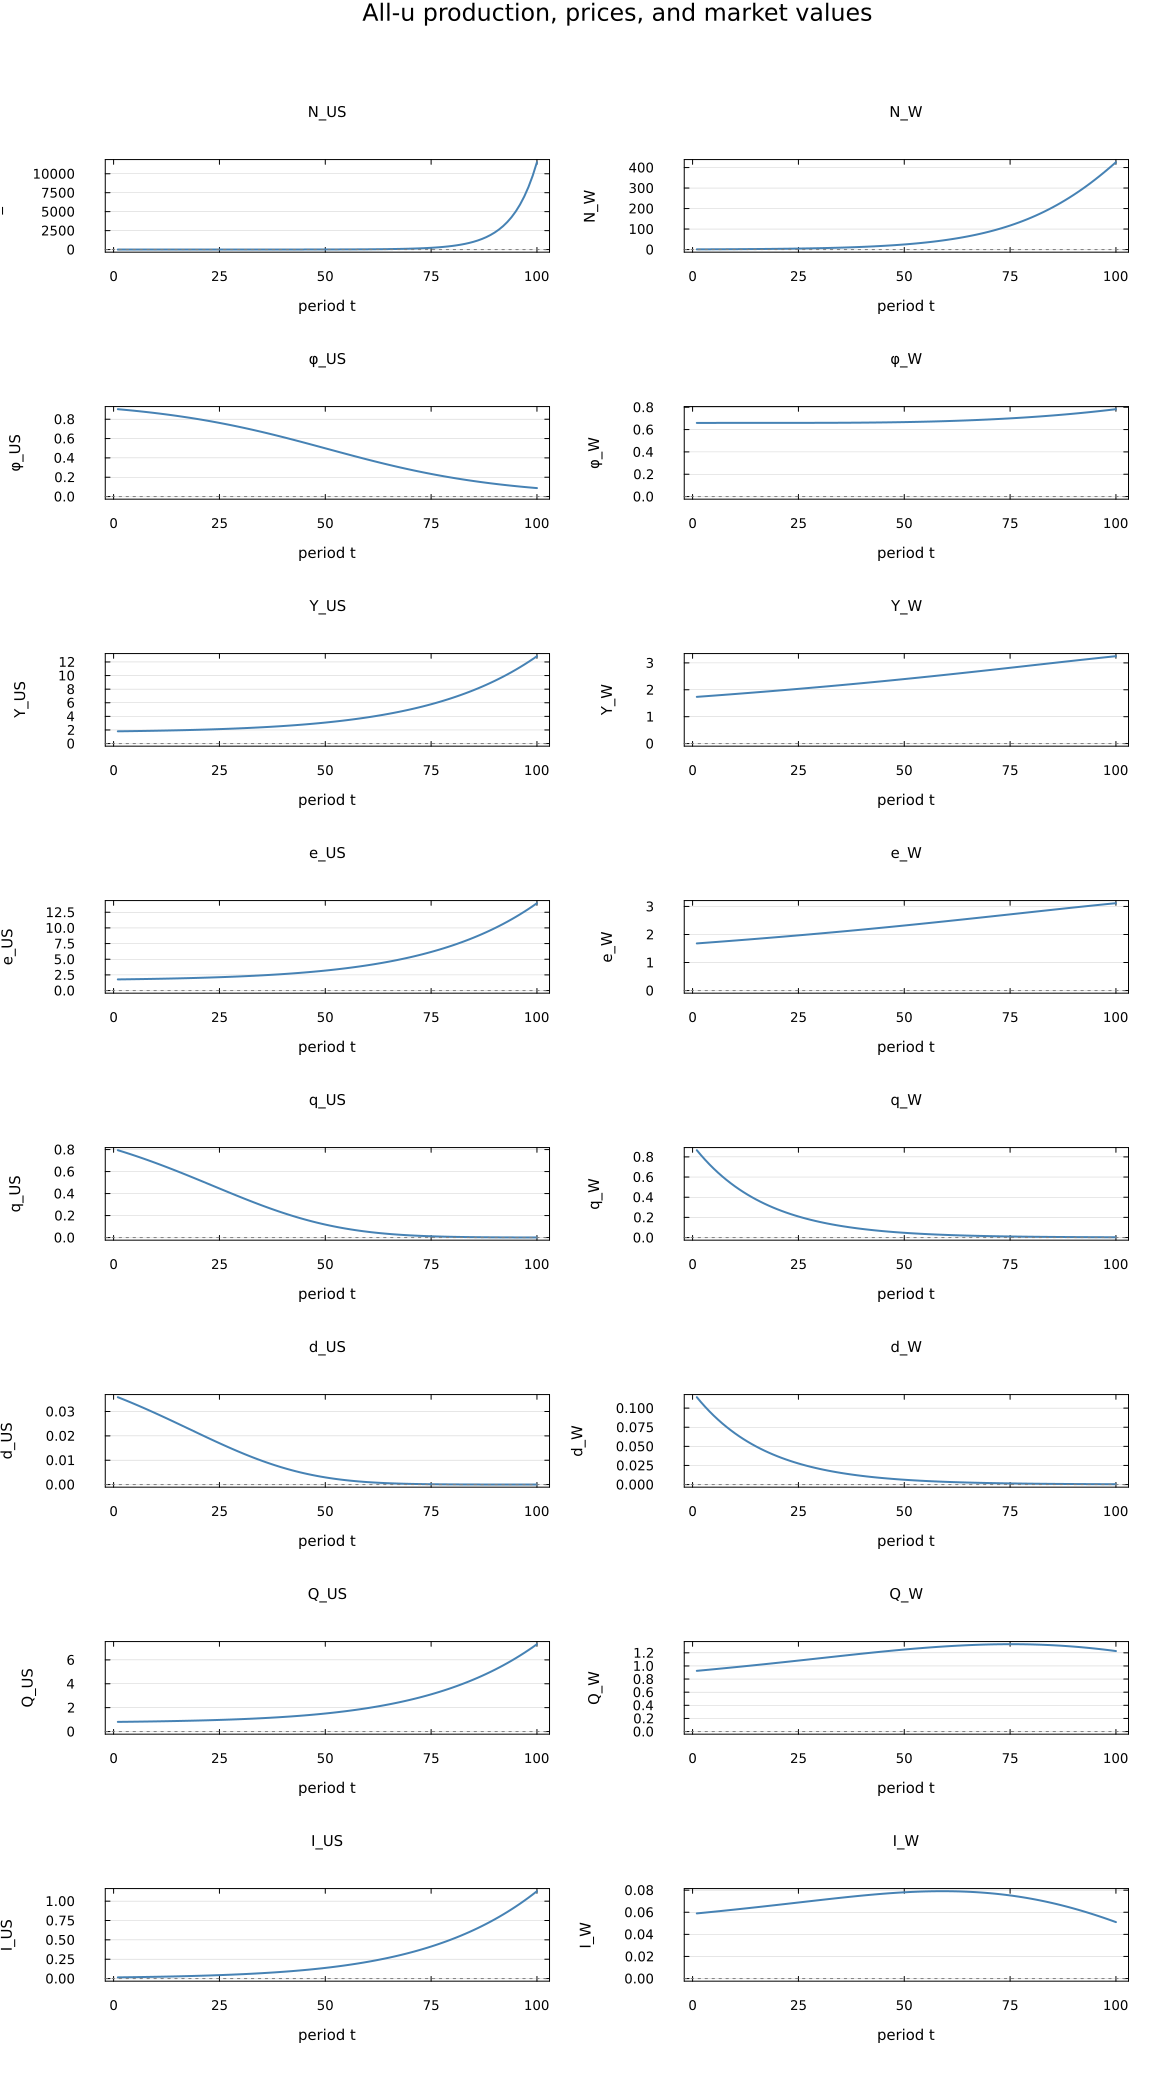

In [4]:

function field_path(result, f::Symbol)
    [getfield(s, f) for s in result.u_path]
end

function plot_field_group(result, fields::Vector{Symbol}, title_label; cols::Int=2, yscale=:identity)
    rows = cld(length(fields), cols)
    panels = Plots.Plot[]
    for f in fields
        vals = field_path(result, f)
        p = plot(tt, vals, lw=2.0, lc=:steelblue, label="",
                 xlabel="period t", ylabel=string(f), title=string(f),
                 yscale=yscale, titlefontsize=10, left_margin=10mm, bottom_margin=8mm)
        hline!(p, [0.0], lc=:gray, ls=:dot, label="")
        push!(panels, p)
    end
    return plot(panels..., layout=(rows, cols), size=(1160, max(320, 260 * rows)),
                plot_title=title_label, margin=6mm)
end

production_price_fields = [:N_US, :N_W, :φ_US, :φ_W, :Y_US, :Y_W, :e_US, :e_W,
                           :q_US, :q_W, :d_US, :d_W, :Q_US, :Q_W, :I_US, :I_W]
asset_portfolio_fields = [:A, :A_star, :S, :S_star, :ω, :ω_star, :θ, :θ_US_star,
                          :R_f, :R_f_W, :Psi]
returns_u_fields = [:R_US_u, :R_W_u, :R_p_u, :R_A_u, :R_p_star_u, :R_A_star_u]
returns_b_fields = [:R_US_b, :R_W_b, :R_p_b, :R_A_b, :R_p_star_b, :R_A_star_b, :residual_norm]

fig_all_u_1 = plot_field_group(blue_result, production_price_fields, "All-u production, prices, and market values"; cols=2)
savefig(fig_all_u_1, joinpath(OUTDIR, "blue_line_all_u_production_prices.png"))
fig_all_u_1


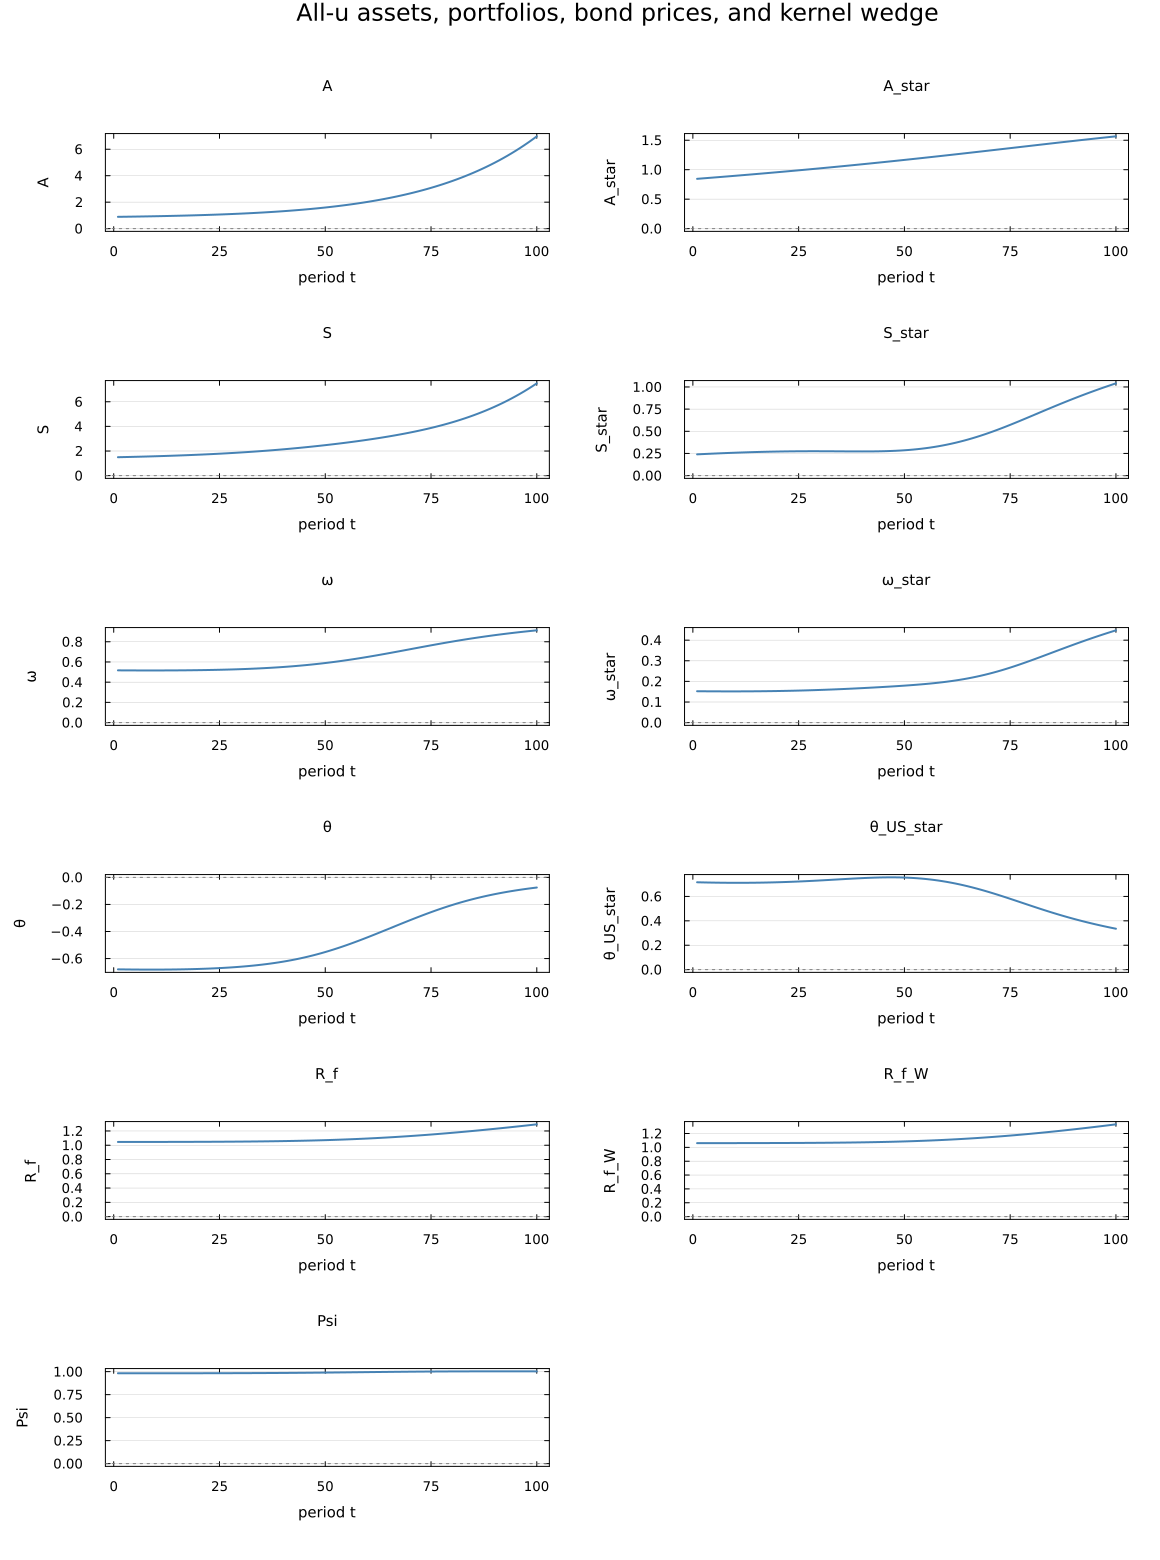

In [5]:

fig_all_u_2 = plot_field_group(blue_result, asset_portfolio_fields, "All-u assets, portfolios, bond prices, and kernel wedge"; cols=2)
savefig(fig_all_u_2, joinpath(OUTDIR, "blue_line_all_u_assets_portfolios.png"))
fig_all_u_2


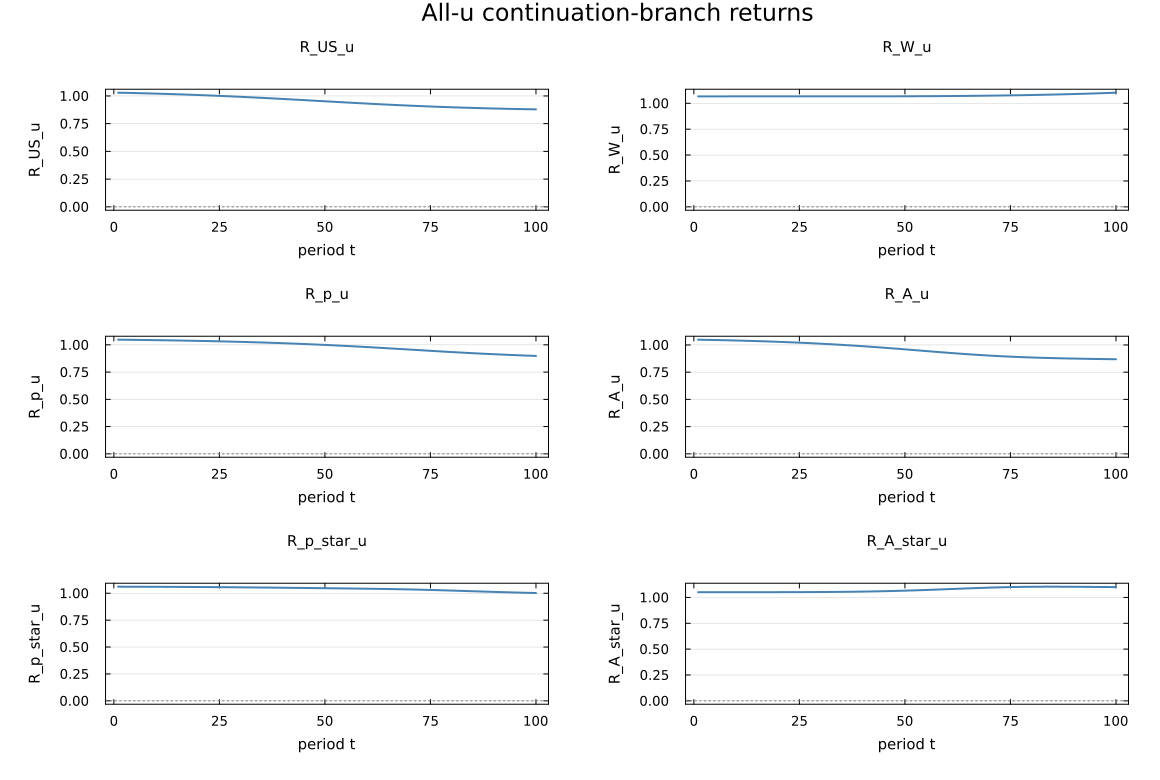

In [6]:

fig_all_u_3 = plot_field_group(blue_result, returns_u_fields, "All-u continuation-branch returns"; cols=2)
savefig(fig_all_u_3, joinpath(OUTDIR, "blue_line_all_u_returns_continuation.png"))
fig_all_u_3


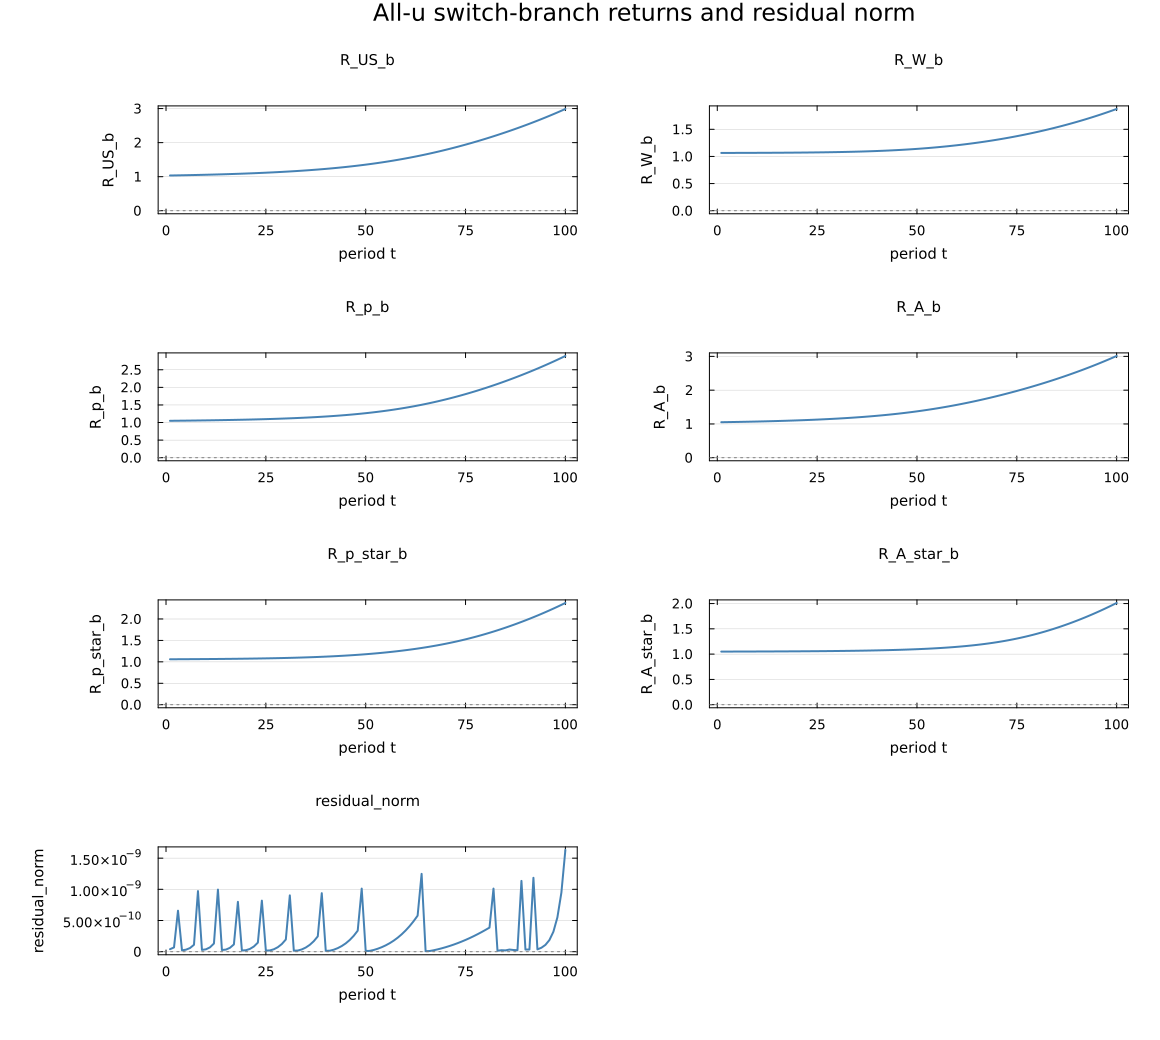

In [7]:

fig_all_u_4 = plot_field_group(blue_result, returns_b_fields, "All-u switch-branch returns and residual norm"; cols=2)
savefig(fig_all_u_4, joinpath(OUTDIR, "blue_line_all_u_returns_switch_residual.png"))
fig_all_u_4


In [8]:

all_fields = collect(fieldnames(typeof(blue_result.u_path[1])))
plotted_fields = vcat(production_price_fields, asset_portfolio_fields, returns_u_fields, returns_b_fields)
unplotted_fields = setdiff(setdiff(all_fields, [:t]), plotted_fields)
println("UPeriodState fields excluding t: ", length(setdiff(all_fields, [:t])))
println("Plotted fields: ", length(plotted_fields))
println("Unplotted fields: ", unplotted_fields)
println("Saved all-u path figures to ", OUTDIR)


UPeriodState fields excluding t: 40


Plotted fields: 40
Unplotted fields: Symbol

[]
Saved all-u path figures to outputs_v43/blue_line_vartheta080



## 3. `Q_US/e_US` demand vs production decomposition

This reproduces the decomposition used in `08_v9_parameter_sweeps.ipynb` and section 8 of `09_v9_phi_decay_aUS_sweeps.ipynb` for the single blue-line calibration:

\[
\frac{Q_{US,t}}{e_{US,t}}
= \frac{\omega_t S_t}{e_{US,t}} + \frac{\omega_t^* S_t^*}{e_{US,t}}
= \frac{w_{H,t}}{a_{US} e_{US,t}} + \frac{(1-\varphi_{US,t})H_{US}w_{H,t}}{e_{US,t}}.
\]


Q_e_final,Q_us_demand_e_final,Q_row_demand_e_final,Q_wage_cap_e_final,Q_innovation_cap_e_final,demand_add_err_max,production_add_err_max
0.5243,0.4909,0.0334,0.4434,0.0809,4.617e-10,1.665e-16


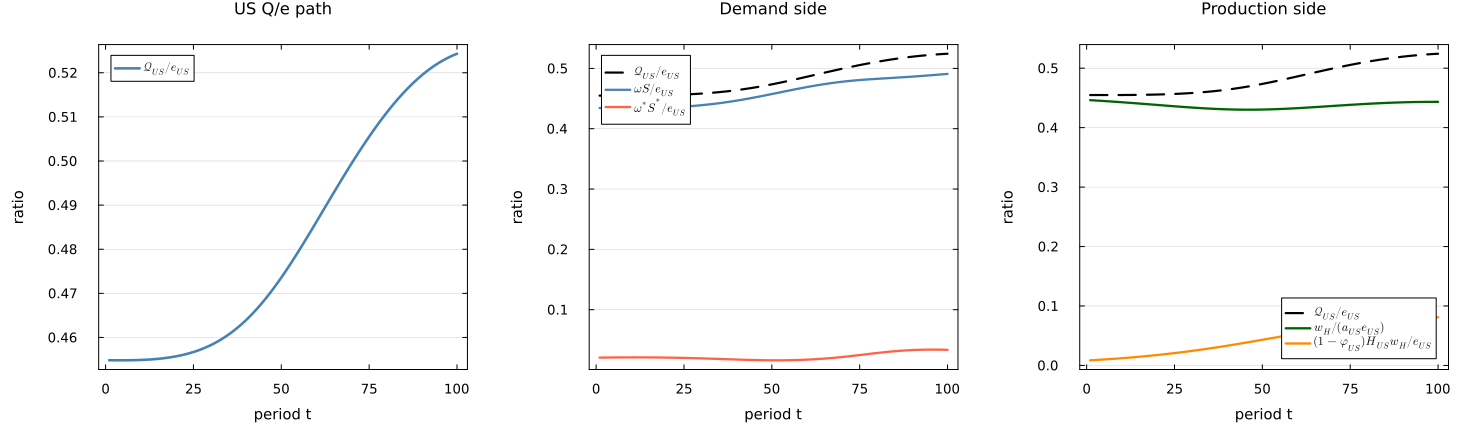

In [9]:

function q_demand_production_decomposition(result)
    p = result.params
    T = length(result.u_path)
    e_US = [s.e_US for s in result.u_path]
    Q_e = [s.Q_US / s.e_US for s in result.u_path]
    Q_us_demand_e = [s.ω * s.S / s.e_US for s in result.u_path]
    Q_row_demand_e = [s.ω_star * s.S_star / s.e_US for s in result.u_path]
    wH_US = [s.q_US * p.a_US * s.N_US for s in result.u_path]
    Q_wage_cap_e = [(wH_US[t] / p.a_US) / e_US[t] for t in 1:T]
    Q_innovation_cap_e = [((1 - result.u_path[t].φ_US) * p.H_US * wH_US[t]) / e_US[t] for t in 1:T]
    return (Q_e=Q_e, Q_us_demand_e=Q_us_demand_e, Q_row_demand_e=Q_row_demand_e,
            Q_wage_cap_e=Q_wage_cap_e, Q_innovation_cap_e=Q_innovation_cap_e,
            wH_e=wH_US ./ e_US,
            demand_err=maximum(abs.(Q_e .- Q_us_demand_e .- Q_row_demand_e)),
            production_err=maximum(abs.(Q_e .- Q_wage_cap_e .- Q_innovation_cap_e)))
end

qd = q_demand_production_decomposition(blue_result)
q_rows = [Dict{String, Any}(
    "Q_e_final" => qd.Q_e[end],
    "Q_us_demand_e_final" => qd.Q_us_demand_e[end],
    "Q_row_demand_e_final" => qd.Q_row_demand_e[end],
    "Q_wage_cap_e_final" => qd.Q_wage_cap_e[end],
    "Q_innovation_cap_e_final" => qd.Q_innovation_cap_e[end],
    "demand_add_err_max" => qd.demand_err,
    "production_add_err_max" => qd.production_err,
)]
show_html_table(q_rows, ["Q_e_final", "Q_us_demand_e_final", "Q_row_demand_e_final", "Q_wage_cap_e_final", "Q_innovation_cap_e_final", "demand_add_err_max", "production_add_err_max"])

write_columns_csv(joinpath(OUTDIR, "blue_line_q_demand_production_decomposition.csv"),
    ["t", "Q_e", "Q_us_demand_e", "Q_row_demand_e", "Q_wage_cap_e", "Q_innovation_cap_e", "phi_US", "wH_e"],
    [tt, qd.Q_e, qd.Q_us_demand_e, qd.Q_row_demand_e, qd.Q_wage_cap_e, qd.Q_innovation_cap_e, field_path(blue_result, :φ_US), qd.wH_e])

p_q_total = plot(tt, qd.Q_e, lw=2.6, lc=:steelblue, label=L"\mathcal{Q}_{US}/e_{US}",
                 xlabel="period t", ylabel="ratio", title="US Q/e path")
p_q_demand = plot(tt, qd.Q_e, lw=2.2, lc=:black, ls=:dash, label=L"\mathcal{Q}_{US}/e_{US}",
                  xlabel="period t", ylabel="ratio", title="Demand side")
plot!(p_q_demand, tt, qd.Q_us_demand_e, lw=2.3, lc=:steelblue, label=L"\omega S/e_{US}")
plot!(p_q_demand, tt, qd.Q_row_demand_e, lw=2.3, lc=:tomato, label=L"\omega^*S^*/e_{US}")
p_q_prod = plot(tt, qd.Q_e, lw=2.2, lc=:black, ls=:dash, label=L"\mathcal{Q}_{US}/e_{US}",
                xlabel="period t", ylabel="ratio", title="Production side")
plot!(p_q_prod, tt, qd.Q_wage_cap_e, lw=2.3, lc=:darkgreen, label=L"w_H/(a_{US}e_{US})")
plot!(p_q_prod, tt, qd.Q_innovation_cap_e, lw=2.3, lc=:darkorange, label=L"(1-\varphi_{US})H_{US}w_H/e_{US}")
fig_q_decomp = plot(p_q_total, p_q_demand, p_q_prod, layout=(1,3), size=(1480, 430), margin=8mm)
savefig(fig_q_decomp, joinpath(OUTDIR, "blue_line_q_demand_production_decomposition.png"))
fig_q_decomp



## 4. NFA components as in `08_v9` / `06_v9`

The portfolio-position identity is

\[
NFA_t=(1-\omega_t)(1-\theta_t)A_t-\omega_t^*(1-\theta_{US,t}^*)A_t^*+\theta_tA_t=A_t-\mathcal Q_{US,t}.
\]

The second row repeats the market-cap and bubble objects used by `nfa_decomposition(result)`.


component_add_err_max,NFA_e_final,home_equity_e_final,foreign_liability_e_final,bond_position_e_final,bubble_drag_e_final
2.072e-09,-0.0243,0.0467,-0.0334,-0.0376,7.670e-06


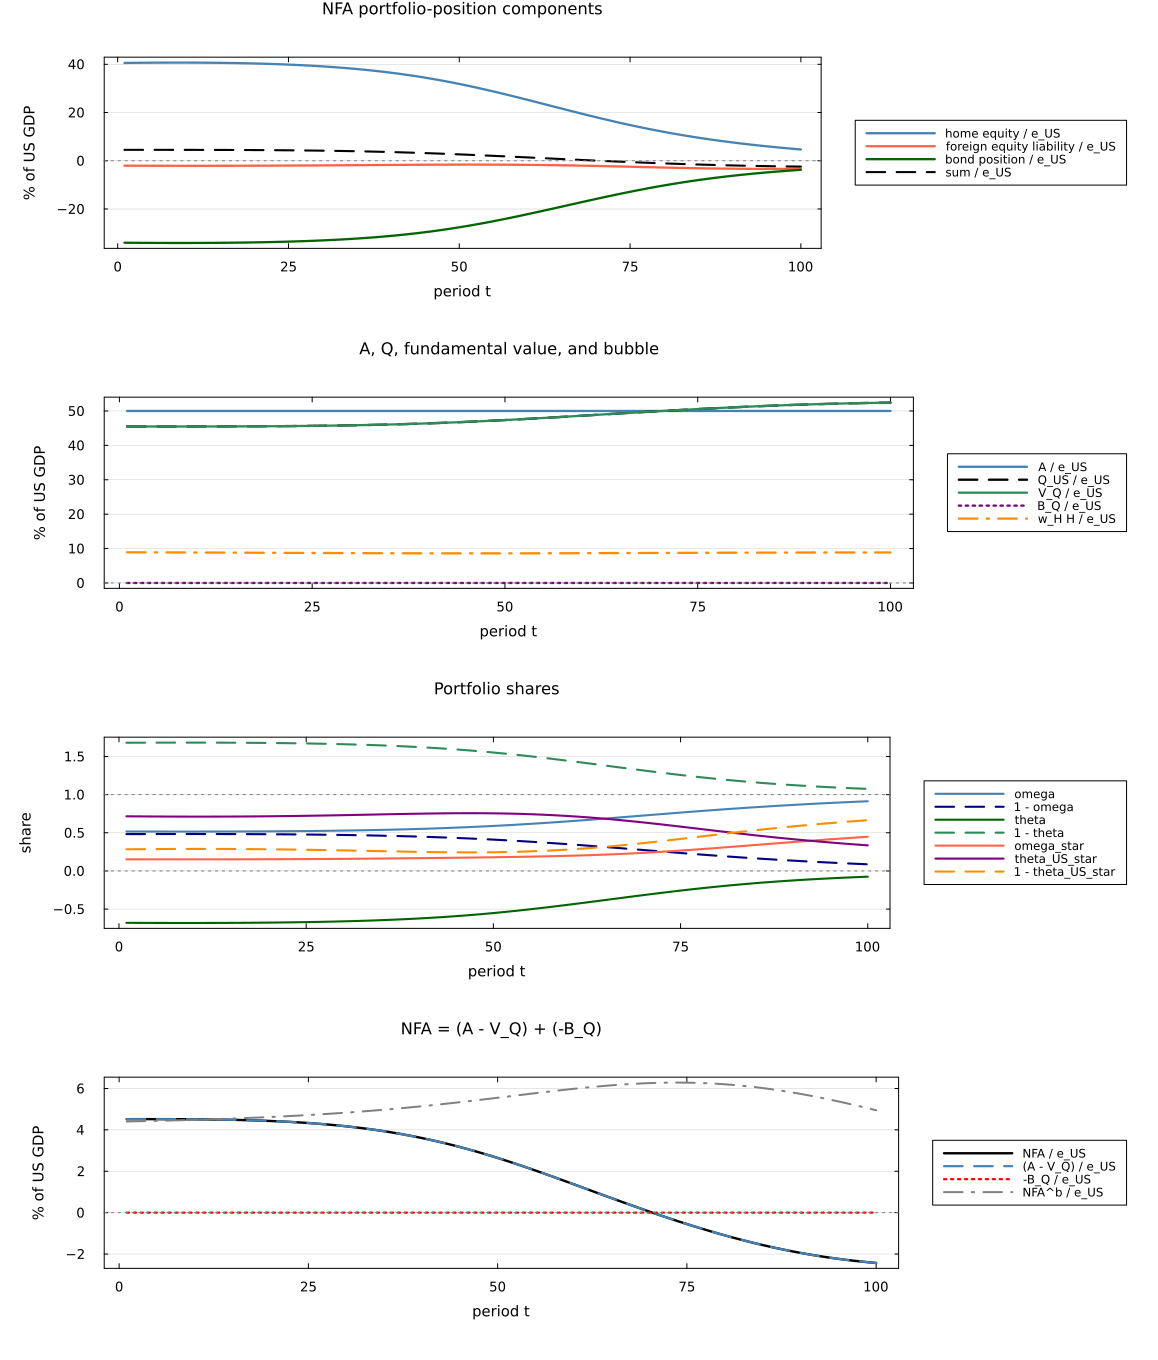

In [10]:

function nfa_components_08(result)
    p = result.params
    nf = nfa_decomposition(result)
    fv = fundamental_value_path(result)
    home_equity = [(1 - s.ω) * (1 - s.θ) * s.A for s in result.u_path]
    foreign_liability = [-s.ω_star * (1 - s.θ_US_star) * s.A_star for s in result.u_path]
    bond_position = [s.θ * s.A for s in result.u_path]
    nfa_sum = home_equity .+ foreign_liability .+ bond_position
    wH_US = [s.q_US * p.a_US * s.N_US * p.H_US for s in result.u_path]
    return (nf=nf, fv=fv, home_equity=home_equity, foreign_liability=foreign_liability,
            bond_position=bond_position, nfa_sum=nfa_sum,
            A_US=[s.A for s in result.u_path], Q_US=nf.Q_US, B_agg=fv.B_agg,
            V_agg=fv.V_agg, wH_US=wH_US,
            omega=[s.ω for s in result.u_path], omega_star=[s.ω_star for s in result.u_path],
            theta=[s.θ for s in result.u_path], theta_US_star=[s.θ_US_star for s in result.u_path],
            add_err=maximum(abs.(nfa_sum .- nf.NFA)))
end

nc = nfa_components_08(blue_result)
show_html_table([Dict{String, Any}(
    "component_add_err_max" => nc.add_err,
    "NFA_e_final" => nc.nf.NFA[end] / e_US[end],
    "home_equity_e_final" => nc.home_equity[end] / e_US[end],
    "foreign_liability_e_final" => nc.foreign_liability[end] / e_US[end],
    "bond_position_e_final" => nc.bond_position[end] / e_US[end],
    "bubble_drag_e_final" => nc.nf.NFA_bubble[end] / e_US[end],
)], ["component_add_err_max", "NFA_e_final", "home_equity_e_final", "foreign_liability_e_final", "bond_position_e_final", "bubble_drag_e_final"])

write_columns_csv(joinpath(OUTDIR, "blue_line_nfa_components_08.csv"),
    ["t", "home_equity", "foreign_liability", "bond_position", "nfa_sum", "NFA", "A_US", "Q_US", "V_agg", "B_agg", "NFA_fund", "NFA_bubble", "NFA_b_cf", "DeltaNFA", "DeltaA", "DeltaV", "DeltaB", "e_US"],
    [tt, nc.home_equity, nc.foreign_liability, nc.bond_position, nc.nfa_sum, nc.nf.NFA, nc.A_US, nc.Q_US, nc.V_agg, nc.B_agg, nc.nf.NFA_fund, nc.nf.NFA_bubble, nc.nf.NFA_b_cf, nc.nf.ΔNFA, nc.nf.ΔA, nc.nf.ΔV, nc.nf.ΔB, e_US])

p_comp = plot(tt, nc.home_equity ./ e_US .* 100, lw=2.3, lc=:steelblue,
              label="home equity / e_US", xlabel="period t", ylabel="% of US GDP",
              title="NFA portfolio-position components", legend=:outerright)
plot!(p_comp, tt, nc.foreign_liability ./ e_US .* 100, lw=2.3, lc=:tomato,
      label="foreign equity liability / e_US")
plot!(p_comp, tt, nc.bond_position ./ e_US .* 100, lw=2.3, lc=:darkgreen, label="bond position / e_US")
plot!(p_comp, tt, nc.nfa_sum ./ e_US .* 100, lw=2.1, lc=:black, ls=:dash, label="sum / e_US")
hline!(p_comp, [0.0], lc=:gray, ls=:dot, label="")

p_assets = plot(tt, nc.A_US ./ e_US .* 100, lw=2.3, lc=:steelblue, label="A / e_US",
                xlabel="period t", ylabel="% of US GDP", title="A, Q, fundamental value, and bubble", legend=:outerright)
plot!(p_assets, tt, nc.Q_US ./ e_US .* 100, lw=2.3, lc=:black, ls=:dash, label="Q_US / e_US")
plot!(p_assets, tt, nc.V_agg ./ e_US .* 100, lw=2.3, lc=:seagreen, label="V_Q / e_US")
plot!(p_assets, tt, nc.B_agg ./ e_US .* 100, lw=2.3, lc=:purple, ls=:dot, label="B_Q / e_US")
plot!(p_assets, tt, nc.wH_US ./ e_US .* 100, lw=2.3, lc=:darkorange, ls=:dashdot, label="w_H H / e_US")
hline!(p_assets, [0.0], lc=:gray, ls=:dot, label="")

p_shares = plot(tt, nc.omega, lw=2.1, lc=:steelblue, label="omega",
                xlabel="period t", ylabel="share", title="Portfolio shares", legend=:outerright)
plot!(p_shares, tt, 1 .- nc.omega, lw=2.1, lc=:navy, ls=:dash, label="1 - omega")
plot!(p_shares, tt, nc.theta, lw=2.1, lc=:darkgreen, label="theta")
plot!(p_shares, tt, 1 .- nc.theta, lw=2.1, lc=:seagreen, ls=:dash, label="1 - theta")
plot!(p_shares, tt, nc.omega_star, lw=2.1, lc=:tomato, label="omega_star")
plot!(p_shares, tt, nc.theta_US_star, lw=2.1, lc=:purple, label="theta_US_star")
plot!(p_shares, tt, 1 .- nc.theta_US_star, lw=2.1, lc=:darkorange, ls=:dash, label="1 - theta_US_star")
hline!(p_shares, [0.0, 1.0], lc=:gray, ls=:dot, label="")

p_bubble_nfa = plot(tt, nc.nf.NFA ./ e_US .* 100, lw=2.4, lc=:black, label="NFA / e_US",
                    xlabel="period t", ylabel="% of US GDP", title="NFA = (A - V_Q) + (-B_Q)", legend=:outerright)
plot!(p_bubble_nfa, tt, nc.nf.NFA_fund ./ e_US .* 100, lw=2.2, lc=:steelblue, ls=:dash, label="(A - V_Q) / e_US")
plot!(p_bubble_nfa, tt, nc.nf.NFA_bubble ./ e_US .* 100, lw=2.2, lc=:red, ls=:dot, label="-B_Q / e_US")
plot!(p_bubble_nfa, tt, nc.nf.NFA_b_cf ./ e_US .* 100, lw=2.0, lc=:gray, ls=:dashdot, label="NFA^b / e_US")
hline!(p_bubble_nfa, [0.0], lc=:gray, ls=:dot, label="")

fig_nfa_components = plot(p_comp, p_assets, p_shares, p_bubble_nfa, layout=(4,1), size=(1160, 1360), margin=8mm)
savefig(fig_nfa_components, joinpath(OUTDIR, "blue_line_nfa_components_08.png"))
fig_nfa_components



## 5. AHP-style NFA accounting: current account vs valuation effects

From the US perspective, define

\[
NFA_t=q_{W,t}n_{W,t}+b_t-q_{US,t}n^*_{US,t},
\]

where the model-implied positions are recovered from portfolio quantities:

\[
q_{W,t}n_{W,t}=(1-\omega_t)(1-\theta_t)A_t,\quad
q_{US,t}n^*_{US,t}=\omega_t^*(1-\theta_{US,t}^*)A_t^*,\quad
b_t=\theta_tA_t.
\]

For `t >= 2` in the stored path, the note's timing convention gives

\[
VA_t=n_{W,t-1}(q_{W,t}-q_{W,t-1})-n^*_{US,t-1}(q_{US,t}-q_{US,t-1}),
\]

\[
CA_t=q_{W,t}(n_{W,t}-n_{W,t-1})-q_{US,t}(n^*_{US,t}-n^*_{US,t-1})+(b_t-b_{t-1}),
\]

\[
RES_t=NFA_t-NFA_{t-1}-CA_t-VA_t.
\]

Following AHP Figure 2, the cumulative series are plotted against `NFA/Y_US`, using `Y_US` as the model analog of US corporate GVA.


NFA_identity_err_max,AHP_RES_abs_max,NFA_Y_final,cum_CA_Y_final,cum_VA_Y_final,cum_RES_Y_final
2.072e-09,1.665e-16,-0.0264,0.2605,-0.2931,-1.080e-18


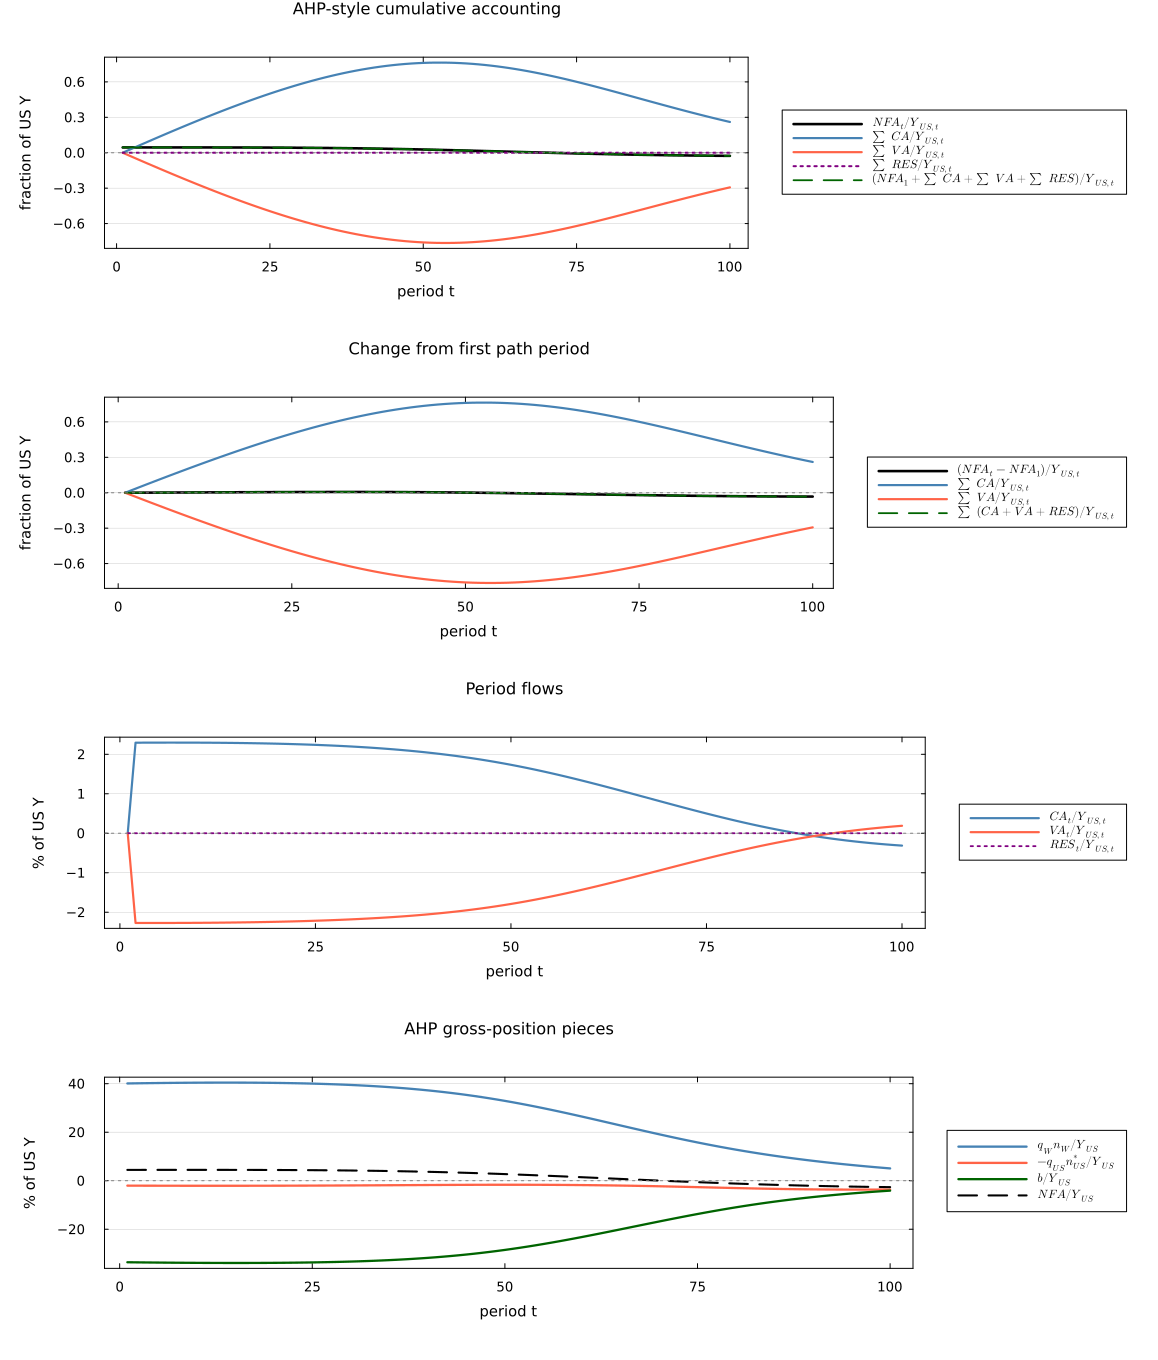

In [11]:

function ahp_style_decomposition(result)
    T = length(result.u_path)
    q_US = [s.q_US for s in result.u_path]
    q_W = [s.q_W for s in result.u_path]
    n_W = [(1 - s.ω) * (1 - s.θ) * s.A / s.q_W for s in result.u_path]
    n_US_star = [s.ω_star * (1 - s.θ_US_star) * s.A_star / s.q_US for s in result.u_path]
    bond = [s.θ * s.A for s in result.u_path]
    NFA = q_W .* n_W .+ bond .- q_US .* n_US_star
    CA = zeros(T)
    VA = zeros(T)
    RES = zeros(T)
    for t in 2:T
        VA[t] = n_W[t - 1] * (q_W[t] - q_W[t - 1]) -
                n_US_star[t - 1] * (q_US[t] - q_US[t - 1])
        CA[t] = q_W[t] * (n_W[t] - n_W[t - 1]) -
                q_US[t] * (n_US_star[t] - n_US_star[t - 1]) +
                (bond[t] - bond[t - 1])
        RES[t] = NFA[t] - NFA[t - 1] - CA[t] - VA[t]
    end
    cum_CA = cumsum(CA)
    cum_VA = cumsum(VA)
    cum_RES = cumsum(RES)
    accounting_line = NFA[1] .+ cum_CA .+ cum_VA .+ cum_RES
    return (q_US=q_US, q_W=q_W, n_W=n_W, n_US_star=n_US_star, bond=bond,
            NFA=NFA, CA=CA, VA=VA, RES=RES,
            cum_CA=cum_CA, cum_VA=cum_VA, cum_RES=cum_RES,
            accounting_line=accounting_line,
            residual_max=maximum(abs.(RES[2:end])),
            nfa_identity_err=maximum(abs.(NFA .- nfa_decomposition(result).NFA)))
end

ahp = ahp_style_decomposition(blue_result)
show_html_table([Dict{String, Any}(
    "NFA_identity_err_max" => ahp.nfa_identity_err,
    "AHP_RES_abs_max" => ahp.residual_max,
    "NFA_Y_final" => ahp.NFA[end] / Y_US[end],
    "cum_CA_Y_final" => ahp.cum_CA[end] / Y_US[end],
    "cum_VA_Y_final" => ahp.cum_VA[end] / Y_US[end],
    "cum_RES_Y_final" => ahp.cum_RES[end] / Y_US[end],
)], ["NFA_identity_err_max", "AHP_RES_abs_max", "NFA_Y_final", "cum_CA_Y_final", "cum_VA_Y_final", "cum_RES_Y_final"])

write_columns_csv(joinpath(OUTDIR, "blue_line_ahp_style_decomposition.csv"),
    ["t", "q_W", "q_US", "n_W", "n_US_star", "bond", "NFA", "CA", "VA", "RES", "cum_CA", "cum_VA", "cum_RES", "accounting_line", "Y_US", "e_US"],
    [tt, ahp.q_W, ahp.q_US, ahp.n_W, ahp.n_US_star, ahp.bond, ahp.NFA, ahp.CA, ahp.VA, ahp.RES, ahp.cum_CA, ahp.cum_VA, ahp.cum_RES, ahp.accounting_line, Y_US, e_US])

p_ahp_fig2 = plot(tt, ahp.NFA ./ Y_US, lw=2.6, lc=:black, label=L"NFA_t/Y_{US,t}",
                  xlabel="period t", ylabel="fraction of US Y", title="AHP-style cumulative accounting", legend=:outerright)
plot!(p_ahp_fig2, tt, ahp.cum_CA ./ Y_US, lw=2.2, lc=:steelblue, label=L"\sum CA/Y_{US,t}")
plot!(p_ahp_fig2, tt, ahp.cum_VA ./ Y_US, lw=2.2, lc=:tomato, label=L"\sum VA/Y_{US,t}")
plot!(p_ahp_fig2, tt, ahp.cum_RES ./ Y_US, lw=2.0, lc=:purple, ls=:dot, label=L"\sum RES/Y_{US,t}")
plot!(p_ahp_fig2, tt, ahp.accounting_line ./ Y_US, lw=1.8, lc=:darkgreen, ls=:dash, label=L"(NFA_1+\sum CA+\sum VA+\sum RES)/Y_{US,t}")
hline!(p_ahp_fig2, [0.0], lc=:gray, ls=:dot, label="")

p_ahp_change = plot(tt, (ahp.NFA .- ahp.NFA[1]) ./ Y_US, lw=2.6, lc=:black,
                    label=L"(NFA_t-NFA_1)/Y_{US,t}", xlabel="period t", ylabel="fraction of US Y",
                    title="Change from first path period", legend=:outerright)
plot!(p_ahp_change, tt, ahp.cum_CA ./ Y_US, lw=2.2, lc=:steelblue, label=L"\sum CA/Y_{US,t}")
plot!(p_ahp_change, tt, ahp.cum_VA ./ Y_US, lw=2.2, lc=:tomato, label=L"\sum VA/Y_{US,t}")
plot!(p_ahp_change, tt, (ahp.cum_CA .+ ahp.cum_VA .+ ahp.cum_RES) ./ Y_US,
      lw=1.8, lc=:darkgreen, ls=:dash, label=L"\sum(CA+VA+RES)/Y_{US,t}")
hline!(p_ahp_change, [0.0], lc=:gray, ls=:dot, label="")

p_ahp_flows = plot(tt, ahp.CA ./ Y_US .* 100, lw=2.2, lc=:steelblue, label=L"CA_t/Y_{US,t}",
                   xlabel="period t", ylabel="% of US Y", title="Period flows", legend=:outerright)
plot!(p_ahp_flows, tt, ahp.VA ./ Y_US .* 100, lw=2.2, lc=:tomato, label=L"VA_t/Y_{US,t}")
plot!(p_ahp_flows, tt, ahp.RES ./ Y_US .* 100, lw=1.8, lc=:purple, ls=:dot, label=L"RES_t/Y_{US,t}")
hline!(p_ahp_flows, [0.0], lc=:gray, ls=:dot, label="")

p_ahp_positions = plot(tt, (ahp.q_W .* ahp.n_W) ./ Y_US .* 100, lw=2.3, lc=:steelblue,
                       label=L"q_W n_W/Y_{US}", xlabel="period t", ylabel="% of US Y",
                       title="AHP gross-position pieces", legend=:outerright)
plot!(p_ahp_positions, tt, -(ahp.q_US .* ahp.n_US_star) ./ Y_US .* 100,
      lw=2.3, lc=:tomato, label=L"-q_{US}n^*_{US}/Y_{US}")
plot!(p_ahp_positions, tt, ahp.bond ./ Y_US .* 100, lw=2.3, lc=:darkgreen, label=L"b/Y_{US}")
plot!(p_ahp_positions, tt, ahp.NFA ./ Y_US .* 100, lw=2.1, lc=:black, ls=:dash, label=L"NFA/Y_{US}")
hline!(p_ahp_positions, [0.0], lc=:gray, ls=:dot, label="")

fig_ahp = plot(p_ahp_fig2, p_ahp_change, p_ahp_flows, p_ahp_positions,
               layout=(4,1), size=(1160, 1360), margin=8mm)
savefig(fig_ahp, joinpath(OUTDIR, "blue_line_ahp_style_decomposition.png"))
fig_ahp



### AHP two-panel component summary

The left panel plots the cumulative AHP accounting components as shares of current-period `Y_US`. The right panel compares `NFA/Y_US` to the reconstructed accounting line, `(NFA_1 + sum CA + sum VA + sum RES)/Y_US`.


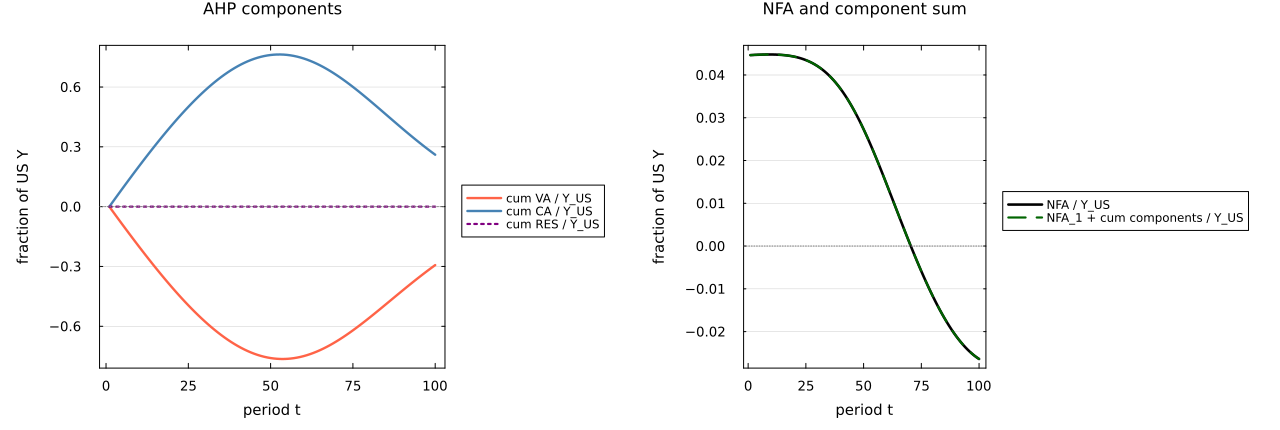

In [12]:

p_ahp_components = plot(tt, ahp.cum_VA ./ Y_US, lw=2.4, lc=:tomato,
                        label="cum VA / Y_US", xlabel="period t",
                        ylabel="fraction of US Y", title="AHP components", legend=:outerright)
plot!(p_ahp_components, tt, ahp.cum_CA ./ Y_US, lw=2.4, lc=:steelblue,
      label="cum CA / Y_US")
plot!(p_ahp_components, tt, ahp.cum_RES ./ Y_US, lw=2.2, lc=:purple, ls=:dot,
      label="cum RES / Y_US")
hline!(p_ahp_components, [0.0], lc=:gray, ls=:dot, label="")

p_ahp_reconstruction = plot(tt, ahp.NFA ./ Y_US, lw=2.6, lc=:black,
                            label="NFA / Y_US", xlabel="period t",
                            ylabel="fraction of US Y", title="NFA and component sum", legend=:outerright)
plot!(p_ahp_reconstruction, tt, ahp.accounting_line ./ Y_US, lw=2.2,
      lc=:darkgreen, ls=:dash, label="NFA_1 + cum components / Y_US")
hline!(p_ahp_reconstruction, [0.0], lc=:gray, ls=:dot, label="")

fig_ahp_two_panel = plot(p_ahp_components, p_ahp_reconstruction,
                         layout=(1,2), size=(1280, 430), margin=8mm)
savefig(fig_ahp_two_panel, joinpath(OUTDIR, "blue_line_ahp_style_two_panel_components.png"))
fig_ahp_two_panel



### AHP VA and CA subcomponents scaled by `Y_US`

This decomposes the AHP valuation and current-account terms into their model subcomponents, each divided by current-period `Y_US`:

\[
VA_t = \underbrace{n_{W,t-1}(q_{W,t}-q_{W,t-1})}_{\text{valuation gain on US-held RoW equity}}
      \underbrace{- n^*_{US,t-1}(q_{US,t}-q_{US,t-1})}_{\text{valuation loss on foreign-held US equity}},
\]

\[
CA_t = \underbrace{q_{W,t}(n_{W,t}-n_{W,t-1})}_{\text{US net RoW-equity purchases}}
      \underbrace{- q_{US,t}(n^*_{US,t}-n^*_{US,t-1})}_{\text{foreign net US-equity purchases}}
      + \underbrace{(b_t-b_{t-1})}_{\text{bond-position change}}.
\]


VA_subcomponent_add_err_max,CA_subcomponent_add_err_max
0.0000,0.0000


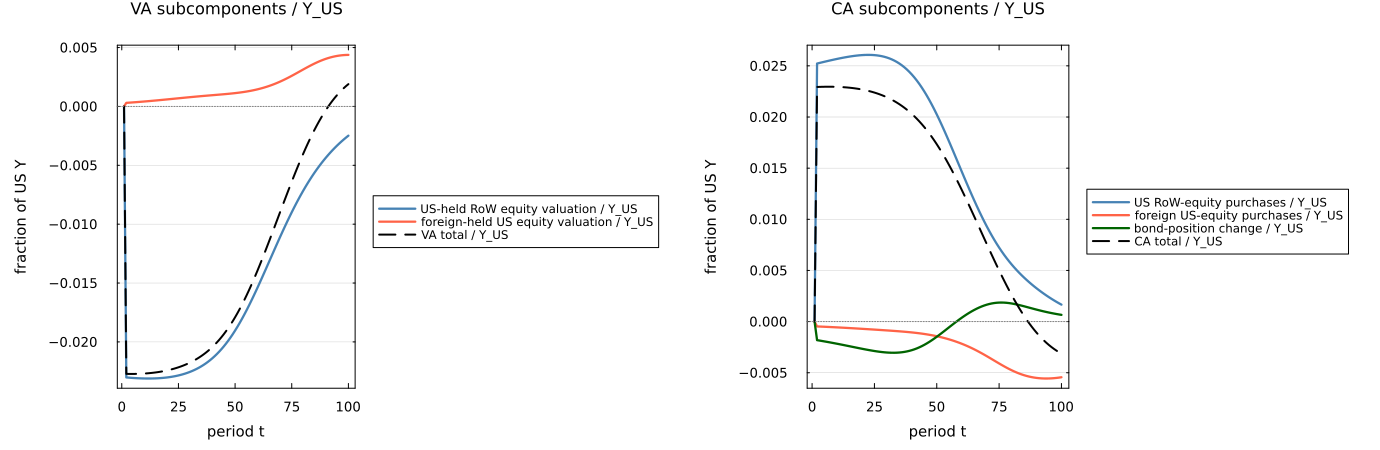

In [13]:

function ahp_va_ca_subcomponents(result)
    T = length(result.u_path)
    q_US = [s.q_US for s in result.u_path]
    q_W = [s.q_W for s in result.u_path]
    n_W = [(1 - s.ω) * (1 - s.θ) * s.A / s.q_W for s in result.u_path]
    n_US_star = [s.ω_star * (1 - s.θ_US_star) * s.A_star / s.q_US for s in result.u_path]
    bond = [s.θ * s.A for s in result.u_path]

    VA_row_equity = zeros(T)
    VA_us_liability = zeros(T)
    CA_row_equity = zeros(T)
    CA_us_liability = zeros(T)
    CA_bond = zeros(T)

    for t in 2:T
        VA_row_equity[t] = n_W[t - 1] * (q_W[t] - q_W[t - 1])
        VA_us_liability[t] = -n_US_star[t - 1] * (q_US[t] - q_US[t - 1])
        CA_row_equity[t] = q_W[t] * (n_W[t] - n_W[t - 1])
        CA_us_liability[t] = -q_US[t] * (n_US_star[t] - n_US_star[t - 1])
        CA_bond[t] = bond[t] - bond[t - 1]
    end

    return (VA_row_equity=VA_row_equity,
            VA_us_liability=VA_us_liability,
            CA_row_equity=CA_row_equity,
            CA_us_liability=CA_us_liability,
            CA_bond=CA_bond,
            VA_add_err=maximum(abs.(VA_row_equity .+ VA_us_liability .- ahp.VA)),
            CA_add_err=maximum(abs.(CA_row_equity .+ CA_us_liability .+ CA_bond .- ahp.CA)))
end

ahp_sub = ahp_va_ca_subcomponents(blue_result)
show_html_table([Dict{String, Any}(
    "VA_subcomponent_add_err_max" => ahp_sub.VA_add_err,
    "CA_subcomponent_add_err_max" => ahp_sub.CA_add_err,
)], ["VA_subcomponent_add_err_max", "CA_subcomponent_add_err_max"])

write_columns_csv(joinpath(OUTDIR, "blue_line_ahp_va_ca_subcomponents_y.csv"),
    ["t", "VA_row_equity_Y", "VA_us_liability_Y", "VA_total_Y", "CA_row_equity_Y", "CA_us_liability_Y", "CA_bond_Y", "CA_total_Y", "Y_US"],
    [tt,
     ahp_sub.VA_row_equity ./ Y_US,
     ahp_sub.VA_us_liability ./ Y_US,
     ahp.VA ./ Y_US,
     ahp_sub.CA_row_equity ./ Y_US,
     ahp_sub.CA_us_liability ./ Y_US,
     ahp_sub.CA_bond ./ Y_US,
     ahp.CA ./ Y_US,
     Y_US])

p_va_sub_y = plot(tt, ahp_sub.VA_row_equity ./ Y_US, lw=2.3, lc=:steelblue,
                  label="US-held RoW equity valuation / Y_US",
                  xlabel="period t", ylabel="fraction of US Y",
                  title="VA subcomponents / Y_US", legend=:outerright)
plot!(p_va_sub_y, tt, ahp_sub.VA_us_liability ./ Y_US, lw=2.3, lc=:tomato,
      label="foreign-held US equity valuation / Y_US")
plot!(p_va_sub_y, tt, ahp.VA ./ Y_US, lw=2.0, lc=:black, ls=:dash,
      label="VA total / Y_US")
hline!(p_va_sub_y, [0.0], lc=:gray, ls=:dot, label="")

p_ca_sub_y = plot(tt, ahp_sub.CA_row_equity ./ Y_US, lw=2.3, lc=:steelblue,
                  label="US RoW-equity purchases / Y_US",
                  xlabel="period t", ylabel="fraction of US Y",
                  title="CA subcomponents / Y_US", legend=:outerright)
plot!(p_ca_sub_y, tt, ahp_sub.CA_us_liability ./ Y_US, lw=2.3, lc=:tomato,
      label="foreign US-equity purchases / Y_US")
plot!(p_ca_sub_y, tt, ahp_sub.CA_bond ./ Y_US, lw=2.3, lc=:darkgreen,
      label="bond-position change / Y_US")
plot!(p_ca_sub_y, tt, ahp.CA ./ Y_US, lw=2.0, lc=:black, ls=:dash,
      label="CA total / Y_US")
hline!(p_ca_sub_y, [0.0], lc=:gray, ls=:dot, label="")

fig_ahp_va_ca_subcomponents_y = plot(p_va_sub_y, p_ca_sub_y,
                                     layout=(1,2), size=(1380, 450), margin=8mm)
savefig(fig_ahp_va_ca_subcomponents_y, joinpath(OUTDIR, "blue_line_ahp_va_ca_subcomponents_y.png"))
fig_ahp_va_ca_subcomponents_y



### Cumulative AHP VA and CA subcomponents scaled by `Y_US`

This cumulates each VA and CA subcomponent through time and divides each cumulative series by current-period `Y_US`. The dashed black lines are the corresponding cumulative total `VA` and `CA` series.


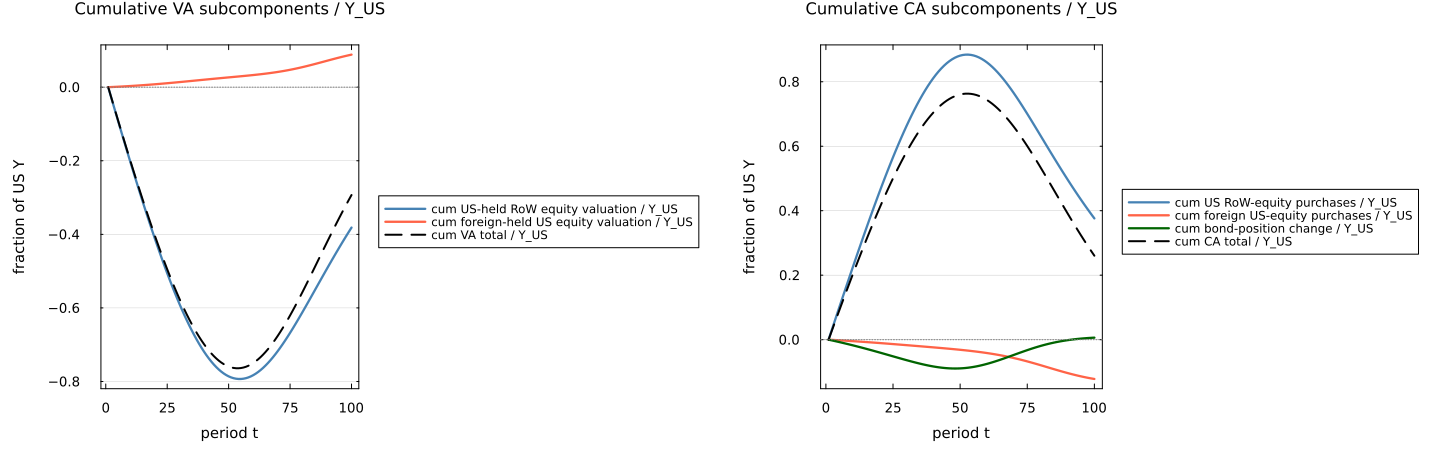

In [14]:

cum_VA_row_equity = cumsum(ahp_sub.VA_row_equity)
cum_VA_us_liability = cumsum(ahp_sub.VA_us_liability)
cum_CA_row_equity = cumsum(ahp_sub.CA_row_equity)
cum_CA_us_liability = cumsum(ahp_sub.CA_us_liability)
cum_CA_bond = cumsum(ahp_sub.CA_bond)

write_columns_csv(joinpath(OUTDIR, "blue_line_ahp_cumulative_va_ca_subcomponents_y.csv"),
    ["t", "cum_VA_row_equity_Y", "cum_VA_us_liability_Y", "cum_VA_total_Y", "cum_CA_row_equity_Y", "cum_CA_us_liability_Y", "cum_CA_bond_Y", "cum_CA_total_Y", "Y_US"],
    [tt,
     cum_VA_row_equity ./ Y_US,
     cum_VA_us_liability ./ Y_US,
     ahp.cum_VA ./ Y_US,
     cum_CA_row_equity ./ Y_US,
     cum_CA_us_liability ./ Y_US,
     cum_CA_bond ./ Y_US,
     ahp.cum_CA ./ Y_US,
     Y_US])

p_cum_va_sub_y = plot(tt, cum_VA_row_equity ./ Y_US, lw=2.3, lc=:steelblue,
                      label="cum US-held RoW equity valuation / Y_US",
                      xlabel="period t", ylabel="fraction of US Y",
                      title="Cumulative VA subcomponents / Y_US", legend=:outerright)
plot!(p_cum_va_sub_y, tt, cum_VA_us_liability ./ Y_US, lw=2.3, lc=:tomato,
      label="cum foreign-held US equity valuation / Y_US")
plot!(p_cum_va_sub_y, tt, ahp.cum_VA ./ Y_US, lw=2.0, lc=:black, ls=:dash,
      label="cum VA total / Y_US")
hline!(p_cum_va_sub_y, [0.0], lc=:gray, ls=:dot, label="")

p_cum_ca_sub_y = plot(tt, cum_CA_row_equity ./ Y_US, lw=2.3, lc=:steelblue,
                      label="cum US RoW-equity purchases / Y_US",
                      xlabel="period t", ylabel="fraction of US Y",
                      title="Cumulative CA subcomponents / Y_US", legend=:outerright)
plot!(p_cum_ca_sub_y, tt, cum_CA_us_liability ./ Y_US, lw=2.3, lc=:tomato,
      label="cum foreign US-equity purchases / Y_US")
plot!(p_cum_ca_sub_y, tt, cum_CA_bond ./ Y_US, lw=2.3, lc=:darkgreen,
      label="cum bond-position change / Y_US")
plot!(p_cum_ca_sub_y, tt, ahp.cum_CA ./ Y_US, lw=2.0, lc=:black, ls=:dash,
      label="cum CA total / Y_US")
hline!(p_cum_ca_sub_y, [0.0], lc=:gray, ls=:dot, label="")

fig_ahp_cumulative_va_ca_subcomponents_y = plot(p_cum_va_sub_y, p_cum_ca_sub_y,
                                                layout=(1,2), size=(1450, 450), margin=8mm)
savefig(fig_ahp_cumulative_va_ca_subcomponents_y, joinpath(OUTDIR, "blue_line_ahp_cumulative_va_ca_subcomponents_y.png"))
fig_ahp_cumulative_va_ca_subcomponents_y



### AHP two-panel component summary scaled by `e_US`

This repeats the previous AHP two-panel figure with every series divided by current-period `e_US` instead of `Y_US`.


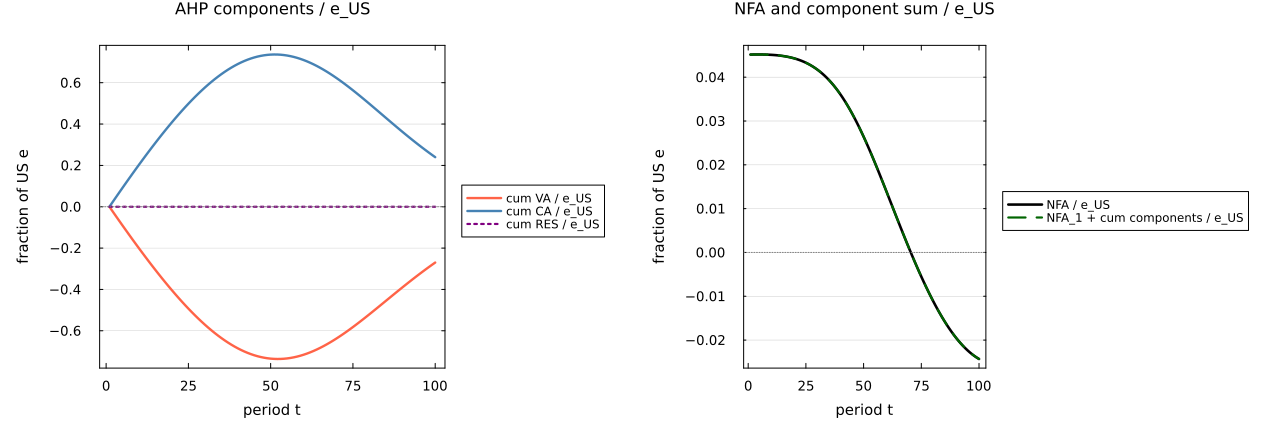

In [15]:

p_ahp_components_e = plot(tt, ahp.cum_VA ./ e_US, lw=2.4, lc=:tomato,
                          label="cum VA / e_US", xlabel="period t",
                          ylabel="fraction of US e", title="AHP components / e_US", legend=:outerright)
plot!(p_ahp_components_e, tt, ahp.cum_CA ./ e_US, lw=2.4, lc=:steelblue,
      label="cum CA / e_US")
plot!(p_ahp_components_e, tt, ahp.cum_RES ./ e_US, lw=2.2, lc=:purple, ls=:dot,
      label="cum RES / e_US")
hline!(p_ahp_components_e, [0.0], lc=:gray, ls=:dot, label="")

p_ahp_reconstruction_e = plot(tt, ahp.NFA ./ e_US, lw=2.6, lc=:black,
                              label="NFA / e_US", xlabel="period t",
                              ylabel="fraction of US e", title="NFA and component sum / e_US", legend=:outerright)
plot!(p_ahp_reconstruction_e, tt, ahp.accounting_line ./ e_US, lw=2.2,
      lc=:darkgreen, ls=:dash, label="NFA_1 + cum components / e_US")
hline!(p_ahp_reconstruction_e, [0.0], lc=:gray, ls=:dot, label="")

fig_ahp_two_panel_e = plot(p_ahp_components_e, p_ahp_reconstruction_e,
                           layout=(1,2), size=(1280, 430), margin=8mm)
savefig(fig_ahp_two_panel_e, joinpath(OUTDIR, "blue_line_ahp_style_two_panel_components_e.png"))
fig_ahp_two_panel_e



## 6. Output files

All generated artifacts are written under `outputs_v43/blue_line_vartheta080/`. The CSV files are intended to make it easy to reuse the solved path outside the notebook; the PNG files mirror the displayed figures.


In [16]:

for f in sort(readdir(OUTDIR))
    println(joinpath(OUTDIR, f))
end


outputs_v43/blue_line_vartheta080/blue_line_ahp_cumulative_va_ca_subcomponents_y.csv
outputs_v43/blue_line_vartheta080/blue_line_ahp_cumulative_va_ca_subcomponents_y.png
outputs_v43/blue_line_vartheta080/blue_line_ahp_style_decomposition.csv
outputs_v43/blue_line_vartheta080/blue_line_ahp_style_decomposition.png
outputs_v43/blue_line_vartheta080/blue_line_ahp_style_two_panel_components.png
outputs_v43/blue_line_vartheta080/blue_line_ahp_style_two_panel_components_e.png
outputs_v43/blue_line_vartheta080/blue_line_ahp_va_ca_subcomponents_y.csv
outputs_v43/blue_line_vartheta080/blue_line_ahp_va_ca_subcomponents_y.png
outputs_v43/blue_line_vartheta080/blue_line_all_u_assets_portfolios.png
outputs_v43/blue_line_vartheta080/blue_line_all_u_endogenous_paths.csv
outputs_v43/blue_line_vartheta080/blue_line_all_u_production_prices.png
outputs_v43/blue_line_vartheta080/blue_line_all_u_returns_continuation.png
outputs_v43/blue_line_vartheta080/blue_line_all_u_returns_switch_residual.png
outputs_v4